In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [5]:
INPUT_SHAPE = (32, 32, 3)
num_classes = 10

# keep copies for plotting (uint8 0-255)
x_train_plot = x_train.copy()
x_test_plot = x_test.copy()

# convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ---------------------------
# 3. Augmentation configs (for creating and labeling augmentation preview samples)
# ---------------------------
augmentation_configs = [
    ("rotation_30", dict(rotation_range=30)),
    ("width_shift_0.2", dict(width_shift_range=0.2)),
    ("height_shift_0.2", dict(height_shift_range=0.2)),
    ("shear_20", dict(shear_range=20.0)),
    ("zoom_0.2", dict(zoom_range=0.2)),
    ("horizontal_flip", dict(horizontal_flip=True)),
    ("brightness_0.5_1.5", dict(brightness_range=(0.5,1.5))),
    ("channel_shift_50", dict(channel_shift_range=50.0)),
    ("fill_mode_nearest_rotate15", dict(rotation_range=15, fill_mode='nearest')),
    ("zoom_and_flip", dict(zoom_range=0.15, horizontal_flip=True)),
]

# ---------------------------
# 4. Create 15 augmented samples (3 rows x 5 cols) and plot them
#    For visibility we avoid rescaling here so images remain 0-255 uint8.
# ---------------------------
n_samples = 15
aug_images = []
aug_titles = []
random.seed(42)
np.random.seed(42)

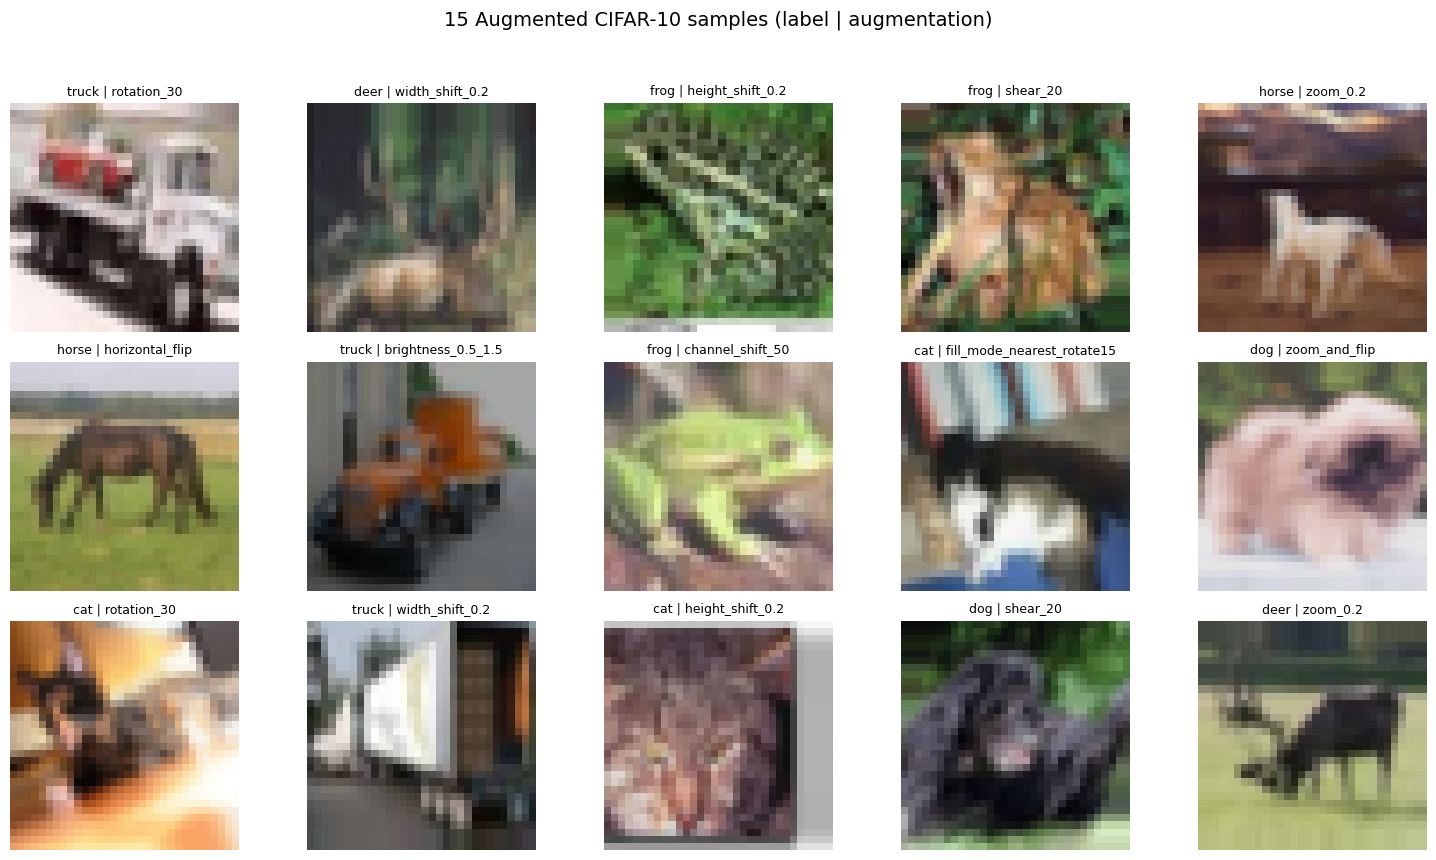

In [8]:
for i in range(n_samples):
    aug_name, params = augmentation_configs[i % len(augmentation_configs)]
    idx = random.randint(0, len(x_train_plot) - 1)
    original = x_train_plot[idx:idx+1]  # shape (1,32,32,3) uint8
    label_name = class_names[y_train[idx]]
    gen = ImageDataGenerator(**params)
    it = gen.flow(original, batch_size=1, shuffle=True, seed=random.randint(0,1_000_000))
    aug_img = next(it)[0].astype(np.uint8)  # augmented 32x32 image
    aug_images.append(aug_img)
    aug_titles.append(f"{label_name} | {aug_name}")

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()
for ax, img, title in zip(axes, aug_images, aug_titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.suptitle("15 Augmented CIFAR-10 samples (label | augmentation)", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [9]:
def build_minimal_cnn(input_shape=INPUT_SHAPE, num_classes=10):
    inp = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    # Block 3 (light)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inp, outputs=out)
    return model

In [10]:
model = build_minimal_cnn(INPUT_SHAPE, num_classes)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

2026-02-23 15:29:56.832805: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,29

 Total params: 404,778 (1.54 MB)

 Trainable params: 403,882 (1.54 MB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.12,
    height_shift_range=0.12,
    horizontal_flip=True,
    zoom_range=0.12,
    shear_range=10.0,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64

train_generator = train_datagen.flow(x_train, y_train_cat, batch_size=BATCH_SIZE, shuffle=True, seed=42)
# For validation we will use the entire test set (rescaled) as validation_data
x_test_rescaled = x_test.astype('float32') / 255.0

# ---------------------------
# 7. Train the model and plot training & validation accuracy/loss
# ---------------------------
EPOCHS = 20
steps_per_epoch = len(x_train) // BATCH_SIZE

# useful callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=(x_test_rescaled, y_test_cat),
    callbacks=callbacks,
    verbose=2
)

Epoch 1/20


/home/zahin/Desktop/AI_LAB/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


KeyboardInterrupt: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
ax1.plot(history.history.get('accuracy', []), label='train_acc')
ax1.plot(history.history.get('val_accuracy', []), label='val_acc')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history.get('loss', []), label='train_loss')
ax2.plot(history.history.get('val_loss', []), label='val_loss')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Training and Validation Accuracy / Loss')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test_rescaled, y_test_cat, verbose=2)
print(f"\nTest loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

# ---------------------------
# 9. Pick 10 random samples from the original test set and plot predictions
#     (2 rows x 5 cols). Titles should show true label and predicted label.
# ---------------------------
n_display = 10
indices = np.random.choice(len(x_test_plot), size=n_display, replace=False)
selected_images = x_test_plot[indices]  # original 32x32 uint8 images for plotting
selected_images_for_pred = selected_images.astype('float32') / 255.0  # scale for model

preds = model.predict(selected_images_for_pred)
pred_labels = np.argmax(preds, axis=1)
true_labels = y_test[indices]

# Plot 2 rows x 5 cols
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for ax, img, true_l, pred_l in zip(axes, selected_images, true_labels, pred_labels):
    ax.imshow(img)
    ax.set_title(f"True: {class_names[int(true_l)]}\nPred: {class_names[int(pred_l)]}", fontsize=10)
    ax.axis('off')

plt.suptitle('10 Random Test Samples: True label vs Prediction', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()